In [ ]:
def end_call(name,error = None, errorMessage = None):
    global monitor
    dict_ = monitor[name].pop()
    dict_['end'] = time.time()
    dict_['duration'] = dict_['end']-dict_['start']
    if error:
        dict_['error'] = 1
        dict_['errorMessage'] = errorMessage
    monitor[name].append(dict_)

<span style="color:hotpink;font-weight: bold; font-size: 20px;">1st Installing Necessary Libraries </span>

In [ ]:
!pip install PyMuPDF pandas openpyxl
!pip install langchain
!pip install langchain-community
!pip install openai
!pip install pandas openpyxl
!pip install scipy scikit-learn
!pip install seaborn

<span style="color:hotpink;font-weight: bold; font-size: 20px;">2nd Importing Key Libraries</span>

In [ ]:
import fitz
import pandas as pd
import numpy as np
import time
import re
import copy
from openai import OpenAI
import openai
import json
import time
import os
import pickle
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error
from scipy.stats import spearmanr
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import classification_report

<span style="color:hotpink;font-weight: bold; font-size: 20px;">Function to extract paragraphs from PDF</span>

<span style="color:hotpink;font-weight: bold; font-size: 20px;">Function to save paragraphs to an Excel file</span>

<span style="color:hotpink;font-weight: bold; font-size: 20px;">Extract and save paragraphs from a PDF</span>

<span style="color:hotpink;font-weight: bold; font-size: 20px;">Read the Human annotated exel file </span>

In [ ]:
df_H = pd.read_excel('/Users/saraalyahya/Dissertation ✅/data/B.xlsx', engine='openpyxl')

print(df_H.head())

   Paragraph Number                                     Paragraph Text  \
0                 1  Blackstone First Quarter 2023 Investor Call Ap...   
1                 2  Moderator: Good day, and welcome to the Blacks...   
2                 3  Weston Tucker: Great thanks, Katie, and good m...   
3                 4  I'd like to remind you that today's call may i...   
4                 5  Also note that nothing on this call constitute...   

  Human Classification  
0                    R  
1                    R  
2                    R  
3                    R  
4                    R  


In [ ]:
num_rows = df_H.shape[0]
print(f"Number of rows: {num_rows}")

Number of rows: 406


<span style="color:orange;font-weight: bold; font-size: 20px;">Relevance Classification: Human vs. LLM [Binary] </span>

In [ ]:
# Convert multi-class sentiment labels to binary relevance
df_H["Relevance"] = df_H["Human Classification"].apply(lambda x: "Relevant" if x in [-2, -1, 0, +1, +2] else "Irrelevant")

In [ ]:
df_H.head()

,Paragraph Number,Paragraph Text,Human Classification,Relevance
0,1,Blackstone First Quarter 2023 Investor Call Ap...,R,Irrelevant
1,2,"Moderator: Good day, and welcome to the Blacks...",R,Irrelevant
2,3,"Weston Tucker: Great thanks, Katie, and good m...",R,Irrelevant
3,4,I'd like to remind you that today's call may i...,R,Irrelevant
4,5,Also note that nothing on this call constitute...,R,Irrelevant


In [ ]:
# Stratified sampling: 10 relevant, 10 irrelevant
sample_relevant = df_H[df_H["Relevance"] == "Relevant"].sample(10, random_state=99)
sample_irrelevant = df_H[df_H["Relevance"] == "Irrelevant"].sample(10, random_state=99) # 99 so that each time i re-run the code it gives me the same 10 samples
df_demo = pd.concat([sample_relevant, sample_irrelevant])

In [ ]:
df_demo.head(2)

,Paragraph Number,Paragraph Text,Human Classification,Relevance
242,243,"single-digit amount in Asia. So, we’re a globa...",0,Relevant
58,59,affect kind of the growth trajectory you see f...,-1,Relevant


<span style="color:hotpink;font-weight: bold; font-size: 20px;">----Open AI</span>

In [ ]:
df_Empty = pd.read_excel('/Users/saraalyahya/Dissertation ✅/data/B empty.xlsx', engine='openpyxl')

print(df_Empty.head())

   Paragraph Number                                     Paragraph Text  \
0                 1  Blackstone First Quarter 2023 Investor Call Ap...   
1                 2  Moderator: Good day, and welcome to the Blacks...   
2                 3  Weston Tucker: Great thanks, Katie, and good m...   
3                 4  I'd like to remind you that today's call may i...   
4                 5  Also note that nothing on this call constitute...   

   Human Classification  
0                   NaN  
1                   NaN  
2                   NaN  
3                   NaN  
4                   NaN  


In [ ]:
num_rows = len(df_Empty)
print(f"Number of rows: {num_rows}")

Number of rows: 406


In [ ]:
client = OpenAI(api_key=, base_url=) # I've removed the api key since it's the companies'

<span style="color:hotpink;font-weight: bold; font-size: 20px;">Binary Prompt</span>

In [ ]:
def build_binary_relevance_prompt(text, demo_df):
    examples = ""
    for _, row in demo_df.iterrows():
        examples += f"Sentence: {row['Paragraph Text'].strip()}\nLabel: {row['Relevance']}\n\n"

    prompt = (
        "You are a financial assistant that classifies text as either Relevant or Irrelevant to financial sentiment.\n"
        "Here are some examples labeled by a human:\n\n"
        f"{examples}"
        "Now classify the following sentence.\n"
        f"Sentence: {text.strip()}\nLabel:"
    )
    return prompt


In [ ]:
def classify_relevance_llm(row, demo_df):
    prompt_text = build_binary_relevance_prompt(row["Paragraph Text"], demo_df)

    try:
        response = client.chat.completions.create(
            # model="gpt-3.5-turbo",
            model="deepseek-chat",
            messages=[
                {"role": "system", "content": "You classify financial text as Relevant or Irrelevant."},
                {"role": "user", "content": prompt_text}
            ],
            max_tokens=3,
            temperature=1.5
        )
        return response.choices[0].message.content.strip()
    except Exception as e:
        return f"Error: {e}"


In [ ]:
df_llm_binary = pd.read_excel("/Users/saraalyahya/Dissertation ✅/data/B empty.xlsx")

start_time = time.time()  # Start the timer

df_llm_binary["LLM Relevance"] = df_llm_binary.apply(lambda row: classify_relevance_llm(row, df_demo), axis=1)

end_time = time.time()  # End the timer

elapsed_time = end_time - start_time
print(f"Time taken: {elapsed_time:.2f} seconds")


Time taken: 1784.09 seconds


In [ ]:
df_llm_binary["LLM Relevance"] = df_llm_binary["LLM Relevance"].str.replace("Label:", "", regex=False).str.strip()

In [ ]:
df_llm_binary.head(10)

,Paragraph Number,Paragraph Text,Human Classification,LLM Relevance
0,1,Blackstone First Quarter 2023 Investor Call Ap...,NaN,Ir
1,2,"Moderator: Good day, and welcome to the Blacks...",NaN,Ir
2,3,"Weston Tucker: Great thanks, Katie, and good m...",NaN,Ir
3,4,I'd like to remind you that today's call may i...,NaN,Ir
4,5,Also note that nothing on this call constitute...,NaN,Ir
5,6,"So on results, we reported GAAP net income for...",NaN,Relevant
6,7,"With that, I'll turn the call over to Steve.",NaN,Ir
7,8,"Steve Schwarzman: Thanks, Weston and good morn...",NaN,Ir
8,9,The first quarter of 2023 represented a turbul...,NaN,Relevant
9,10,These challenges once again highlighted the ex...,NaN,Relevant


<span style="color:hotpink;font-weight: bold; font-size: 20px;">compare llm with human </span>

In [ ]:
df_H.head()

,Paragraph Number,Paragraph Text,Human Classification,Relevance
0,1,Blackstone First Quarter 2023 Investor Call Ap...,R,Irrelevant
1,2,"Moderator: Good day, and welcome to the Blacks...",R,Irrelevant
2,3,"Weston Tucker: Great thanks, Katie, and good m...",R,Irrelevant
3,4,I'd like to remind you that today's call may i...,R,Irrelevant
4,5,Also note that nothing on this call constitute...,R,Irrelevant


In [ ]:
# Merge on Paragraph Number
df_B_merge= df_H.merge(df_llm_binary[["Paragraph Number", "LLM Relevance"]], on="Paragraph Number", how="inner")


In [ ]:
df_B_merge.head()

,Paragraph Number,Paragraph Text,Human Classification,Relevance,LLM Relevance
0,1,Blackstone First Quarter 2023 Investor Call Ap...,R,Irrelevant,Ir
1,2,"Moderator: Good day, and welcome to the Blacks...",R,Irrelevant,Ir
2,3,"Weston Tucker: Great thanks, Katie, and good m...",R,Irrelevant,Ir
3,4,I'd like to remind you that today's call may i...,R,Irrelevant,Ir
4,5,Also note that nothing on this call constitute...,R,Irrelevant,Ir


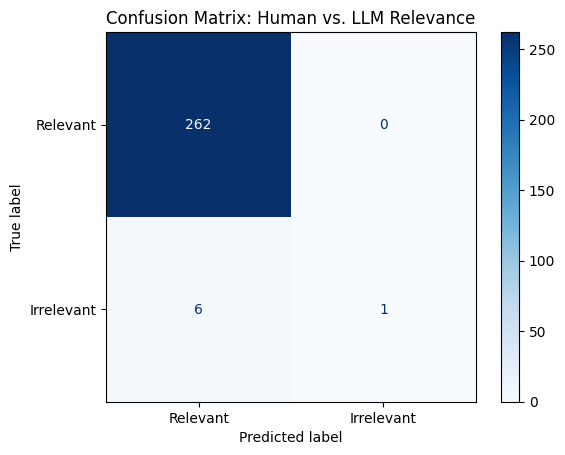

In [ ]:
y_true = df_B_merge["Relevance"]
y_pred = df_B_merge["LLM Relevance"]

labels = ["Relevant", "Irrelevant"]
cm = confusion_matrix(y_true, y_pred, labels=labels)

# Display confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix: Human vs. LLM Relevance")
plt.show()


- the LLM correctly identified 292 sentences as Relevant, matching human judgment (True Positives)

- the LLM correctly identified 30 sentences as Irrelevant (True Negatives)

- the LLM incorrectly labeled 83 irrelevant sentences as Relevant (False Positives)

- the LLM missed 1 relevant sentence, calling it Irrelevant (False Negative)


In [ ]:
# Clean string labels
y_true = [label.replace("Label: ", "").strip() for label in y_true]
y_pred = [label.replace("Label: ", "").strip() for label in y_pred]

In [ ]:
print("Unique y_true labels:", set(y_true))
print("Unique y_pred labels:", set(y_pred))

Unique y_true labels: {'Relevant', 'Irrelevant'}
Unique y_pred labels: {'The sentence is', 'Relevant', 'The sentence "', 'The sentence discusses', 'The label for', 'Ir', 'The sentence appears', 'The sentence can', 'Irrelevant'}


In [ ]:
#print(classification_report(y_true, y_pred, target_names=["Relevant", "Irrelevant"]))
print(classification_report(y_true,y_pred,labels=["Relevant", "Irrelevant"],target_names=["Relevant", "Irrelevant"], zero_division=0 ))

              precision    recall  f1-score   support

    Relevant       0.98      0.89      0.93       293
  Irrelevant       1.00      0.01      0.02       113

   micro avg       0.98      0.65      0.78       406
   macro avg       0.99      0.45      0.48       406
weighted avg       0.98      0.65      0.68       406



- 79% of the LLM's predictions match the human annotations

Relevant Class:

- Precision: 0.97 → When the LLM says a sentence is relevant, it's correct 97% of the time

- Recall: 0.27 → It captures only 27% of all human-labeled relevant sentences

- F1 Score: 0.42 → Very limited balance; the LLM misses most relevant content despite high precision

Irrelevant Class:

- Precision: 0.78 → When the LLM says a sentence is irrelevant, it's correct 78% of the time

- Recall: 1.00 → It catches all irrelevant sentences

- F1 Score: 0.87 → Very strong; LLM is overly conservative, favoring irrelevant classification

<span style="color:hotpink;font-weight: bold; font-size: 20px;">Ive added this code so i can do a text comparison (manually) for my paper</span>

In [ ]:
# False Positives
fp = df_B_merge[(df_B_merge["Relevance"] == "Irrelevant") & (df_B_merge["LLM Relevance"] == "Relevant")]
print(len(fp))

# False Negatives
fn = df_B_merge[(df_B_merge["Relevance"] == "Relevant") & (df_B_merge["LLM Relevance"] == "Irrelevant")]
print(len(fn))

# print(fn)

6
0


In [ ]:
fp.to_excel("bs_Binary_fp.xlsx")

In [ ]:
fn.to_excel("bs_Binary_fn.xlsx")

<span style="color:orange;font-weight: bold; font-size: 20px;">Sentiment Classification: Human vs. LLM [Ordinal]</span>

In [ ]:
# Only keep relevant sentiment classes (-2 to +2)
df_Relv = df_H[df_H["Human Classification"].isin([-2, -1, 0, 1, 2])]

In [ ]:
df_Relv.head(2)

,Paragraph Number,Paragraph Text,Human Classification,Relevance
5,6,"So on results, we reported GAAP net income for...",0,Relevant
8,9,The first quarter of 2023 represented a turbul...,-2,Relevant


In [ ]:
# Take 5 examples per class
example_dict = {}
for label in [-2, -1, 0, 1, 2]:
    samples = df_Relv[df_Relv["Human Classification"] == label].sample(5, random_state=99)
    example_dict[label] = samples["Paragraph Text"].tolist()


<span style="color:hotpink;font-weight: bold; font-size: 20px;">Prompt</span>

In [ ]:
def build_few_shot_prompt(text, example_dict):
    label_description = {
        -2: "Strongly Negative",
        -1: "Negative",
        0: "Neutral",
        1: "Positive",
        2: "Strongly Positive"
    }

    example_block = "Here are example paragraphs labeled by a human annotator:\n\n"
    for label, texts in example_dict.items():
        for t in texts:
            example_block += f"Sentence: {t.strip()}\nLabel: {label} ({label_description[label]})\n\n"

    classification_prompt = (
        f"{example_block}"
        "Now classify the sentiment of the following paragraph using one of these exact labels: -2, -1, 0, +1, +2.\n"
        "-2 = Strongly Negative\n"
        "-1 = Negative\n"
        " 0 = Neutral\n"
        "+1 = Positive\n"
        "+2 = Strongly Positive\n\n"
        "**Important Rules:**\n"
        "- Only return the numeric label: -2, -1, 0, +1, or +2.\n"
        "- Do not explain.\n\n"
        f"Paragraph: {text.strip()}\nLabel:"
    )

    return classification_prompt


In [ ]:
def classify_ordinal_sentiment(row, example_dict):
    prompt = build_few_shot_prompt(row["Paragraph Text"], example_dict)

    try:
        response = client.chat.completions.create(
            #model="gpt-3.5-turbo",
            model="deepseek-chat",
            messages=[
                {"role": "system", "content": "You are a financial sentiment classifier. Use only human-labeled examples to make consistent predictions."},
                {"role": "user", "content": prompt}
            ],
            max_tokens=5,
            temperature=1.5
        )
        return response.choices[0].message.content.strip()
    except Exception as e:
        return f"Error: {e}"


In [ ]:
def classify_ordinal_sentiment(row, example_dict):
    prompt = build_few_shot_prompt(row["Paragraph Text"], example_dict)

    try:
        response = client.chat.completions.create(
            #model="gpt-3.5-turbo",
            model="deepseek-chat",
            messages=[
                {"role": "system", "content": "You are a financial sentiment classifier. Use only human-labeled examples to make consistent predictions."},
                {"role": "user", "content": prompt}
            ],
            max_tokens=5,
            temperature=1.5
        )
        return response.choices[0].message.content.strip()
    except Exception as e:
        return f"Error: {e}"


In [ ]:
##### takes 6.32 mins

In [ ]:
start_time = time.time()  # Start the timer

df_Empty["LLM Sentiment"] = df_Empty.apply(lambda row: classify_ordinal_sentiment(row, example_dict), axis=1)


end_time = time.time()  # End the timer

elapsed_time = end_time - start_time
print(f"Time taken: {elapsed_time:.2f} seconds")


Time taken: 1783.69 seconds


<span style="color:hotpink;font-weight: bold; font-size: 20px;">compare llm with human </span>

In [ ]:
df_O_merge = df_Relv.merge(df_Empty[["Paragraph Number", "LLM Sentiment"]], on="Paragraph Number", how="inner")

In [ ]:
df_O_merge.head(10)

,Paragraph Number,Paragraph Text,Human Classification,Relevance,LLM Sentiment
0,6,"So on results, we reported GAAP net income for...",0,Relevant,2
1,9,The first quarter of 2023 represented a turbul...,-2,Relevant,-2
2,10,These challenges once again highlighted the ex...,2,Relevant,2
3,11,"perpetual strategies. In our funds, we seek to...",1,Relevant,1
4,12,The safety of Blackstone’s approach extends to...,1,Relevant,2
5,13,"In real estate, an area of heightened external...",1,Relevant,2
6,14,"Today, investor sentiment toward real estate h...",1,Relevant,+1
7,15,"In credit, higher interest rates and much high...",1,Relevant,1
8,16,Our limited partners recognize Blackstone as a...,1,Relevant,1
9,17,"money to work is in a risk-off world, when sen...",-1,Relevant,1


In [ ]:
num_rows = len(df_O_merge)
print(f"Number of rows: {num_rows}")

Number of rows: 293


In [ ]:
# to count total rows before dropping
total_rows = len(df_O_merge)

# to count how many rows are missing either in the human or LLM label
rows_with_missing = df_O_merge[["Human Classification", "LLM Sentiment"]].isna().any(axis=1).sum()

print(f"Total rows: {total_rows}")
print(f"Rows with missing values: {rows_with_missing}")
print(f"Rows remaining after drop: {total_rows - rows_with_missing}")


Total rows: 293
Rows with missing values: 0
Rows remaining after drop: 293


In [ ]:
# to mack sure it's integers

In [ ]:
df_O_merge["Human Classification"] = df_O_merge["Human Classification"].astype(int)
df_O_merge["LLM Sentiment"] = df_O_merge["LLM Sentiment"].astype(int)

In [ ]:
df_O_merge.head()

,Paragraph Number,Paragraph Text,Human Classification,Relevance,LLM Sentiment
0,6,"So on results, we reported GAAP net income for...",0,Relevant,2
1,9,The first quarter of 2023 represented a turbul...,-2,Relevant,-2
2,10,These challenges once again highlighted the ex...,2,Relevant,2
3,11,"perpetual strategies. In our funds, we seek to...",1,Relevant,1
4,12,The safety of Blackstone’s approach extends to...,1,Relevant,2


### Evaluation

<span style="color:hotpink;font-weight: bold; font-size: 20px;"> Metrics 1: Exact Match Accuracy </span>

In [ ]:
# to extract the true and predicted labels
y_true = df_O_merge["Human Classification"]
y_pred = df_O_merge["LLM Sentiment"]

def exact_match_accuracy(y_true, y_pred):
    return (y_true == y_pred).mean()


In [ ]:
# to calculate accuracy
exact_accuracy = exact_match_accuracy(y_true, y_pred)

# to display result
print(f" Exact Match Accuracy (excluding 'R'): {exact_accuracy:.2%}") # to convert it to a percentage and show 2 decimals


 Exact Match Accuracy (excluding 'R'): 45.39%


In [ ]:
#this means that just below half the cases, LLM’s sentiment prediction matched my human label exactly

<span style="color:hotpink;font-weight: bold; font-size: 20px;"> Metrics 2: MAE </span>

In [ ]:
mae = mean_absolute_error(y_true, y_pred)
print(f"Mean Absolute Error (MAE): {mae:.2f}")


Mean Absolute Error (MAE): 0.77


In [ ]:
total_rows = len(df_O_merge)

print(f"Total rows: {total_rows}")

Total rows: 293


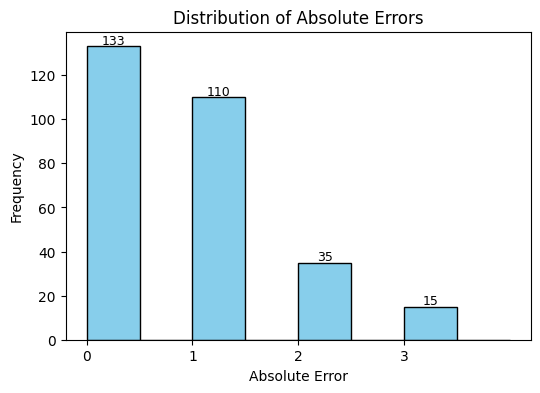

In [ ]:
errors = abs(y_true - y_pred)

# Create bins
bins = np.arange(0, max(errors)+1.5, 0.5)

# ✅ Create the figure first
plt.figure(figsize=(6, 4))

# Plot the histogram and capture the counts and bin edges
counts, bin_edges, patches = plt.hist(errors, bins=bins, edgecolor='black', color='skyblue')

# Add labels
for count, edge in zip(counts, bin_edges[:-1]):
    if count > 0:
        plt.text(edge + 0.25, count + 1, str(int(count)), ha='center', fontsize=9)

# Plot settings
plt.title("Distribution of Absolute Errors")
plt.xlabel("Absolute Error")
plt.ylabel("Frequency")
plt.xticks(np.arange(0, max(errors)+1, 1))
plt.show()


- this chart shows how wrong the AI was compared to human labels

- each bar tells us how many times the AI was off by a certain amount

What each bar means:

- 0: AI was exactly right (it predicted the same as the human) → 130 times

- 1: AI was close, but off by 1 (for example: human's annotation was 0, it said +1) → 102 times

- 2: AI was moderately off (for example: human's annotation was -1, it said +1) → 41 times

- 3: AI was very off (for example: human's annotation was +2, it said -1) → 16 times

- 4: AI was extremely off (for example: human's annotation was -2, it said +2) → 4 times



<span style="color:hotpink;font-weight: bold; font-size: 20px;"> Metrics 3: Spearman Rank Correlation </span>

In [ ]:

spearman_corr, _ = spearmanr(y_true, y_pred)
print(f"Spearman Rank Correlation: {spearman_corr:.2f}")


Spearman Rank Correlation: 0.62


- this means there's a weak positive relationship between the AI's predictions and human annotations — when human annotations goes up, the AI's prediction usually goes up too, but not always

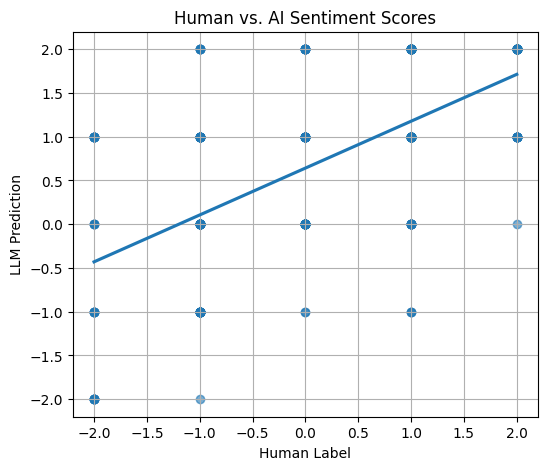

In [ ]:
# make sure y_true and y_pred are defined
y_true = df_O_merge["Human Classification"]
y_pred = df_O_merge["LLM Sentiment"]

# create the scatter + trend line plot
plt.figure(figsize=(6, 5))
sns.regplot(x=y_true, y=y_pred, ci=None, scatter_kws={'alpha': 0.6})
plt.title("Human vs. AI Sentiment Scores")
plt.xlabel("Human Label")
plt.ylabel("LLM Prediction")
plt.grid(True)
plt.show()


In [ ]:
def exact_match_accuracy(y_true, y_pred):
    return (y_true == y_pred).mean()

print("Evaluation Summary (Relevant Only):")
print(f"Exact Match Accuracy:        {exact_match_accuracy(y_true, y_pred):.2%}")
print(f"Mean Absolute Error (MAE):   {mae:.2f}")
print(f"Spearman Rank Correlation:   {spearman_corr:.2f}")


Evaluation Summary (Relevant Only):
Exact Match Accuracy:        45.39%
Mean Absolute Error (MAE):   0.77
Spearman Rank Correlation:   0.62


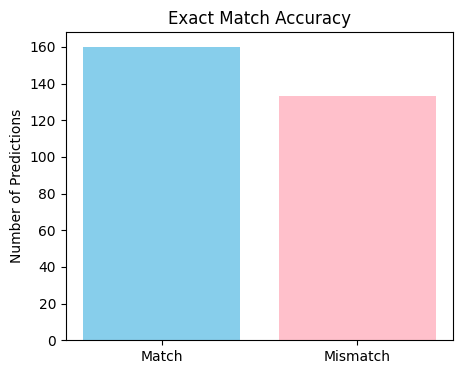

In [ ]:
# exact matches
match = (y_true == y_pred)
match_counts = match.value_counts()


plt.figure(figsize=(5, 4))
plt.bar(['Match', 'Mismatch'], match_counts, color=['skyblue', 'pink'])
plt.title("Exact Match Accuracy")
plt.ylabel("Number of Predictions")
plt.show()


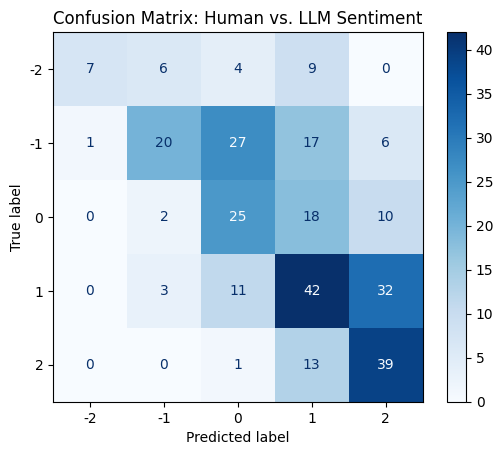

In [ ]:
y_true = df_O_merge["Human Classification"]
y_pred = df_O_merge["LLM Sentiment"]

labels = [-2, -1, 0, 1, 2]
cm = confusion_matrix(y_true, y_pred, labels=labels)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix: Human vs. LLM Sentiment")
plt.show()


- row 1, column 1: 42 → Model correctly predicted +1 when the human label was +1

- row 1, column 2: 35 → Model predicted +2 instead of +1 (slight overestimation)

- row 0, column 1: 27 → Model predicted +1 instead of 0 (moderate overestimation)

- row 0, column 2: 10 → Model predicted +2 instead of 0 (strong overestimation)

- row -1, column 1: 25 → Model predicted +1 instead of -1 (mild reversal)

- row 2, column 1: 5 → Model predicted +1 instead of +2 (underestimation)

- row 2, column 2: 46 → Model correctly predicted +2 when the human label was +2

- row -2, column 0: 7 → Model predicted -2 correctly

- row -2, column 3: 7 → Model predicted +1 instead of -2 (severe reversal)

- row -2, column 4: 4 → Model predicted +2 instead of -2 (extreme reversal)

In [ ]:
# False Negatives: LLM underestimates sentiment
false_negatives = df_O_merge[df_O_merge["LLM Sentiment"] < df_O_merge["Human Classification"]]

# False Positives: LLM overestimates sentiment
false_positives = df_O_merge[df_O_merge["LLM Sentiment"] > df_O_merge["Human Classification"]]

# Display results
print(f"False Negatives (LLM underestimated sentiment): {len(false_negatives)}")
print(false_negatives[["Paragraph Number", "Paragraph Text", "Human Classification", "LLM Sentiment"]].head())

print("\nFalse Positives (LLM overestimated sentiment):", len(false_positives))
print(false_positives[["Paragraph Number", "Paragraph Text", "Human Classification", "LLM Sentiment"]].head())


False Negatives (LLM underestimated sentiment): 31
    Paragraph Number                                     Paragraph Text  \
10                18  One final note from me: earlier this week, S&P...   
23                33  Fourth - our latest fund-raising cycle has pos...   
24                34  push into the energy transition space with a c...   
26                36  In closing, despite the market’s near-term cha...   
32                44  While the environment for realizations is like...   

    Human Classification  LLM Sentiment  
10                     2              1  
23                     2              1  
24                     2              1  
26                     2              1  
32                     0             -1  

False Positives (LLM overestimated sentiment): 129
    Paragraph Number                                     Paragraph Text  \
0                  6  So on results, we reported GAAP net income for...   
4                 12  The safety of Blacksto

In [ ]:
false_negatives.to_excel("bs_Ordinal_fn.xlsx")

In [ ]:
false_positives.to_excel("bs_Ordinal_fp.xlsx")

<span style="color:hotpink;font-weight: bold; font-size: 20px;"> Metrics 4: Per-Class Metrics </span>

In [ ]:
print(classification_report(y_true, y_pred, labels=[-2, -1, 0, 1, 2]))


              precision    recall  f1-score   support

          -2       0.88      0.27      0.41        26
          -1       0.65      0.28      0.39        71
           0       0.37      0.45      0.41        55
           1       0.42      0.48      0.45        88
           2       0.45      0.74      0.56        53

    accuracy                           0.45       293
   macro avg       0.55      0.44      0.44       293
weighted avg       0.51      0.45      0.44       293

